In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Define what we need from the table
metrics = ['SARI', 'COMET', 'MAE']
datasets = ['Med-EASi', 'SimPA']  # M and S in the table
control_attrs = ['FKGL', 'Char Compression']

# Hardcode the actual model names from JSON
models = {
    'Llama': ['Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct', 'Llama-3.1-8B-Instruct', 'Llama-2-13b-chat-hf'],
    'Qwen': ['Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B']
}
    
print("Models:", models)
print("Control Attributes:", control_attrs)
print("Datasets:", datasets)
print("Metrics:", metrics)

Models: {'Llama': ['Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct', 'Llama-3.1-8B-Instruct', 'Llama-2-13b-chat-hf'], 'Qwen': ['Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B']}
Control Attributes: ['FKGL', 'Char Compression']
Datasets: ['Med-EASi', 'SimPA']
Metrics: ['SARI', 'COMET', 'MAE']


In [3]:
# Load the JSON file
import json

with open('./../output/sft_results/all_results.json', 'r') as f:
    data = json.load(f)

In [4]:

results = {metric: {attr: {ds: {family: [] for family in ['Llama', 'Qwen']} 
                            for ds in datasets} 
                    for attr in control_attrs} 
           for metric in ['SARI', 'COMET', 'MAE']}

for family, model_list in models.items():
    for idx, model_name in enumerate(model_list):
        if model_name not in data:
            print(f"Warning: {model_name} not found in data")
            continue
        
        # Extract for each dataset and control attribute
        for ds in datasets:
            if ds not in data[model_name]:
                print(f"Warning: {ds} not found for {model_name}")
                continue
                
            for attr in control_attrs:
                # The JSON has different naming - check both
                attr_key = 'CHAR_COMPRESSION' if attr == 'Char Compression' else attr
                
                if attr_key not in data[model_name][ds]:
                    print(f"Warning: {attr_key} not found for {model_name}/{ds}")
                    continue
                
                attr_data = data[model_name][ds][attr_key]
                
                # Extract SARI and COMET from mean_metrics
                if 'mean_metrics' in attr_data:
                    if 'SARI' in attr_data['mean_metrics']:
                        while len(results['SARI'][attr][ds][family]) <= idx:
                            results['SARI'][attr][ds][family].append(0)
                        results['SARI'][attr][ds][family][idx] = attr_data['mean_metrics']['SARI']['mean']
                    
                    if 'COMET' in attr_data['mean_metrics']:
                        while len(results['COMET'][attr][ds][family]) <= idx:
                            results['COMET'][attr][ds][family].append(0)
                        results['COMET'][attr][ds][family][idx] = attr_data['mean_metrics']['COMET']['mean']
                
                # Extract MAE from losses
                if 'losses' in attr_data and 'MAE' in attr_data['losses']:
                    while len(results['MAE'][attr][ds][family]) <= idx:
                        results['MAE'][attr][ds][family].append(0)
                    results['MAE'][attr][ds][family][idx] = attr_data['losses']['MAE']


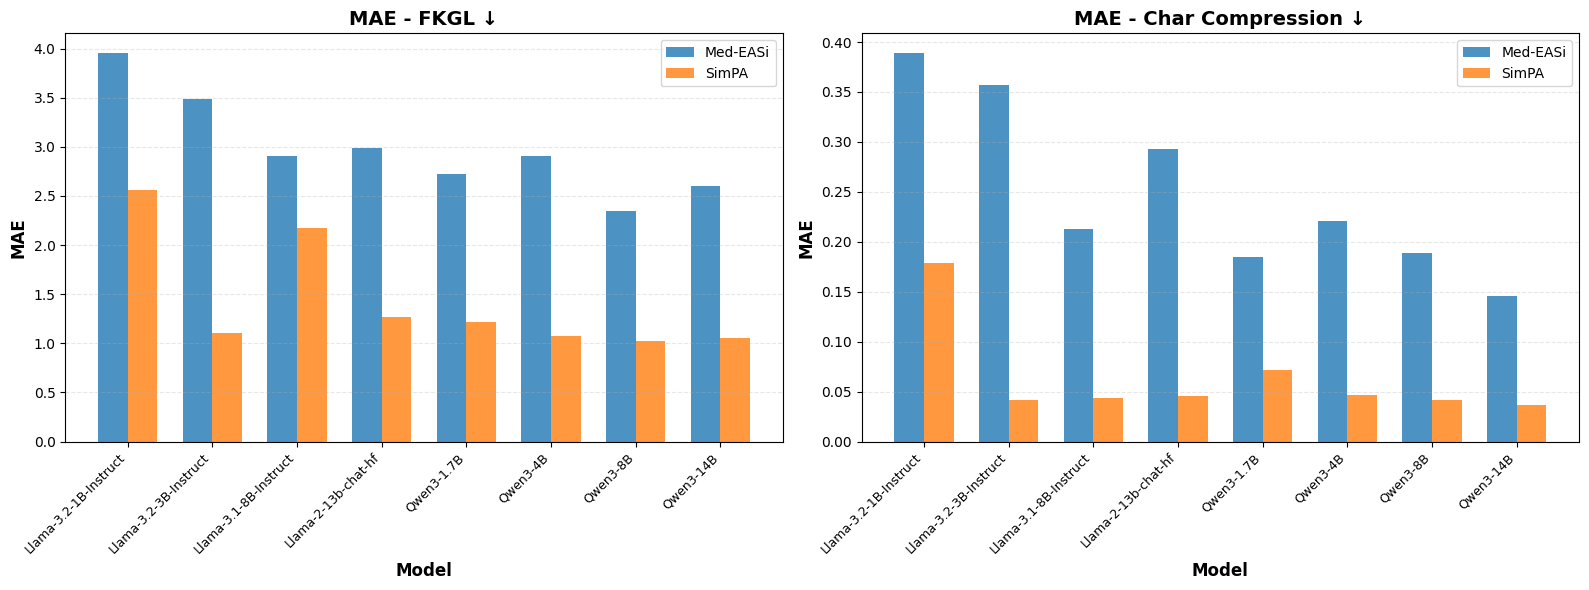

In [5]:
# Create 2 side-by-side plots for MAE only
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_width = 0.35
x_positions = np.arange(8)  # 4 Llama + 4 Qwen models

for idx, attr in enumerate(control_attrs):
    ax = axes[idx]
    offset = -0.5 * bar_width
    
    # Plot each dataset
    for ds in datasets:
        values = results['MAE'][attr][ds]['Llama'] + results['MAE'][attr][ds]['Qwen']
        ax.bar(x_positions + offset, values, bar_width, label=ds, alpha=0.8)
        offset += bar_width
    
    # Formatting
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
    ax.set_title(f'MAE - {attr} ↓', fontsize=14, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(models['Llama'] + models['Qwen'], 
                        rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./../visualizations/mae_comparison.png', dpi=300, bbox_inches='tight')
plt.show()